#**Dog/Cat using Neural Network**

  Dataset : [kaggle DogCatClassification](https://www.kaggle.com/datasets/aleemaparakatta/cats-and-dogs-mini-dataset?utm_)

##importing necessary libraries/data

In [30]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from PIL import Image #load img data into PyTorch
from torchvision import transforms #convert img to tnsor
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

In [2]:
device='cuda' if torch.cuda.is_available() else 'cpu'
print('Device : ',device)

Device :  cuda


##Loading the data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
os.listdir('/content/drive/MyDrive')

['covid-19.csv',
 'Colab Notebooks',
 'Indian_rental_prices.csv',
 'House Price India.csv',
 'Housing_price_prediction_.pkl',
 'Housing_price_model.joblib',
 'Housing_price_prediction_.joblib',
 'diabetes_prediction_dataset.csv',
 'model_classification_.joblib',
 'riceClassification.csv',
 'dog-cat_img_data']

In [5]:
os.listdir('/content/drive/MyDrive/dog-cat_img_data')

['cats_set', 'dogs_set']

##Resizing the Image

In [6]:
data_path='/content/drive/MyDrive/dog-cat_img_data'
cat_path = data_path +'/cats_set'
dog_path= data_path +'/dogs_set'

print('Cats : ', len(os.listdir(cat_path)))
print('Dogs : ', len(os.listdir(dog_path)))
print('\nExample Cat file : ')
print(os.listdir(cat_path)[:5])
print("\nExample dog files:")
print(os.listdir(dog_path)[:5])

Cats :  500
Dogs :  500

Example Cat file : 
['cat.4021.jpg', 'cat.4020.jpg', 'cat.4032.jpg', 'cat.4044.jpg', 'cat.4003.jpg']

Example dog files:
['dog.4005.jpg', 'dog.4027.jpg', 'dog.4028.jpg', 'dog.4042.jpg', 'dog.4011.jpg']


File :  cat.4021.jpg
Size :  (399, 311)
Mode :  RGB


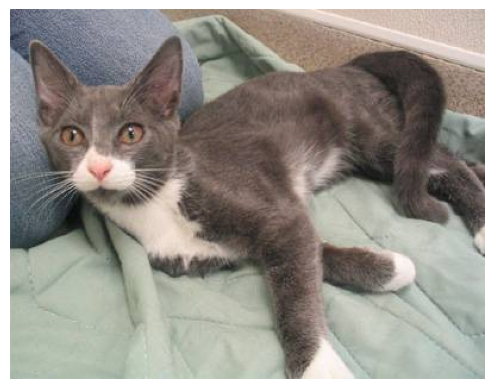

In [7]:
cat_file=os.listdir(cat_path)[0]  #stores the file name of cat img on the folder cats_set with index=0
img_path=os.path.join(cat_path,cat_file) #joins the file name to the cat_path leading to a img path
img=Image.open(img_path) #loads the img file into memory

print('File : ',cat_file)
print('Size : ', img.size)
print('Mode : ',img.mode)

plt.imshow(img) #shows the img on screen with matplotlib.pyplot
plt.axis('off')
plt.show()

In [8]:
#transform=transforms.Compose([transforms.Resize(224*224)]) #Resize image into 224*224

transform=transforms.Resize((224,224))


Origibal size :  (399, 311)
Resized img size :  (224, 224)


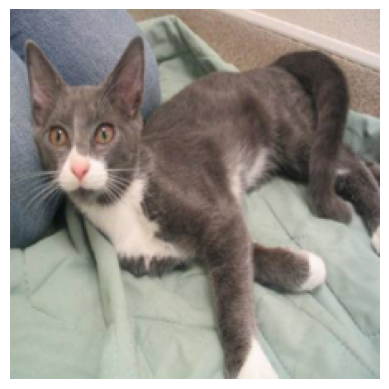

In [9]:
resize_img=transform(img)
print('Origibal size : ',img.size)
print('Resized img size : ',resize_img.size)
plt.imshow(resize_img)
plt.axis('off')
plt.show()

##Resing and converting to tensors and testing on single image

In [10]:
transform=transforms.Compose([
    (transforms.Resize((224,224))),
    (transforms.ToTensor())
])

tensor_img=transform(img)

print(f'''
Typr : {type(tensor_img)}
Shape : {tensor_img.shape}
min pixel val : {tensor_img.min()}
max pixel val : {tensor_img.max()}''')


Typr : <class 'torch.Tensor'>
Shape : torch.Size([3, 224, 224])
min pixel val : 0.027450980618596077
max pixel val : 1.0


##Transforming the dataset through the class

###Adding the data into array :
- x (img_path)
- y (labels)

In [11]:
x=[]
y=[]

#CAT
for file in os.listdir(cat_path):
  x.append(os.path.join(cat_path,file))
  y.append(0)
#DOG
for file in os.listdir(dog_path):
  x.append(os.path.join(dog_path,file))
  y.append(1)

###**CatDogDataset class**

In [12]:
class CatDogDataset(Dataset):
  def __init__(self,x,y,transform):
    super().__init__()
    self.x=x
    self.y=y
    self.transform=transform

  def __len__(self):
    return len(self.x)

  def __getitem__(self,index):  #index exist for both x,y in the array
    img_path=self.x[index]      #returns the location for an image in array x
    label=self.y[index]         #returns the label i.e. 1/0 for the same index in array y
    img=Image.open(img_path).convert('RGB') #loads the image into memory using it's img_path
    img=self.transform(img)     #apply transform to the img i.e. resize & .ToTensor()
    return img,label

In [13]:
transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset=CatDogDataset(x,y,transform)

In [14]:
img,label=dataset[0]
print(f'''
      Total images : {len(dataset)}
      Image Shape  : {img.shape}
      Label        : {label}''')


      Total images : 1000
      Image Shape  : torch.Size([3, 224, 224])
      Label        : 0


###train_test_split

In [15]:
#70% train, 15% test, 15% validation

x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=.3,random_state=42,stratify=y) #random_state is a seed point , when split happens it starts from a same point/index
x_val,x_test,y_val,y_test= train_test_split(x_test,y_test,test_size=.5,random_state=42,stratify=y_test) #stratify=y means when data is split it maintains the same ratio of cat and dog as initial i.e. 1:1

In [16]:
train_dataset= CatDogDataset(x_train,y_train,transform)
test_dataset= CatDogDataset(x_test,y_test,transform)
val_dataset= CatDogDataset(x_val,y_val,transform)

###DataLoader

In [17]:
train_loader= DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader= DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader= DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

##**class CNN :** Feeding the DataLoader to the Model(CNN)


In [18]:
class CNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1=nn.Conv2d( #Conv2d -> covulation operation on img
        in_channels=3,
        out_channels=16,
        #out_channel creates different filter/property of the img such as edge, texture, vertical pattern, etc.
        kernel_size=3, #this makes a 3X3 filter/matrix throgh which the model looks into the img
        padding=1 #adds extra pixels around the border so we dont losses informationt in the edges

    )
    self.pool=nn.MaxPool2d(kernel_size=2)
    '''
    the kernel_size=2 reates a 2X2 view wino=dow which looks into a matrix
    and picks the Max number and goes on thus returning a new matrix
    for example if theres a matrix
    1 2 4 6 7 8
    3 3 5 6 9 0
    1 0 3 4 5 6
    9 2 3 4 7 7
    the nn.MaxPool2d(kernel_size=2) returns
    3 6 9
    9 4 7  the matrix went from (4,6) --> (2,3)
    '''

    self.conv2=nn.Conv2d(
        in_channels=16,
        out_channels=32,
        kernel_size=3,
        padding=1
    )

    self.fc1=nn.Linear(
        32*(56*56),
        128
    )
    self.fc2=nn.Linear(
        128,
        1
    )

  def forward(self,x):
    x=self.conv1(x) #(32,16,224,224)
    x=torch.relu(x)
    x=self.pool(x) #(32,16,112,112)

    x=self.conv2(x)
    x=torch.relu(x)
    x=self.pool(x) #(32,32,56,56)

    x=torch.flatten(x,start_dim=1) #(32, 100352)


    #now x is (32,32,56,56) -> 32 img , 32 channels, 56*56 pixels
    #now we must CONVERT 'X' INTO A LONG VECTOR i.e. FLATTEN it.
    #(32,32,56,56) --> (32,(32*(56*56))) --> (32,100352)

    x=self.fc1(x)  # 100352 ->128
    x=torch.relu(x)
    x=self.fc2(x)  #128 -> 1

    return x
  '''
  def forward(self,x):
    print(len(x))
    print('initial',x.shape)
    x=self.conv1(x)
    x=torch.relu(x)
    print('cov1',x.shape)
    x=self.pool(x)
    print('pool1',x.shape)

    x=self.conv2(x)
    print('conv2',x.shape)
    x=torch.relu(x)
    x=self.pool(x)
    print('pool2',x.shape)

    x=torch.flatten(x,start_dim=1)
    print('flatten',x.shape)

    x=self.fc1(x)
    x=torch.relu(x)
    x=self.fc2(x)
    '''


(224,224) -> pool -> (112,112) -> pool -> (56,56) -> linear(fc1) -> 128 -> fc2 -> 1

###Making Prediction

In [19]:
model=CNN()

In [20]:
images, labels = next(iter(train_loader))#returns 2 array, one with images and one with lable

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])


In [21]:
output=model(images)
print(output.shape)

torch.Size([32, 1])


###Loss function

In [22]:
loss_fx=nn.BCEWithLogitsLoss() # Binary Cross-Entrophy designed for binary error clculation
optimizer =torch.optim.Adam(
    model.parameters(),
    lr=.001
)

output are [32,1] while labels are [32] thus we must make them [32,1]

In [23]:
labels=labels.float().unsqueeze(1)
#.unsqueeze(1) adds another dimension at position 1 i.e before : [1,2,3] ; after :[[1],[2],[3]]

loss=loss_fx(output,labels)
print('Loss',loss)

Loss tensor(0.6888, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)


###Training Loop

In [24]:
epoches=20
for epoch in range(epoches) :
  model.train()
  for images,labels in train_loader:
    output=model(images)
    labels=labels.float().unsqueeze(1)
    loss=loss_fx(output,labels)
    model.zero_grad()
    loss.backward()

    optimizer.step()

  print(f'Epoch :{epoch+1}; Loss : {loss.item()}')

Epoch :1; Loss : 0.6787452697753906
Epoch :2; Loss : 0.6648475527763367
Epoch :3; Loss : 0.5933797955513
Epoch :4; Loss : 0.6449361443519592
Epoch :5; Loss : 0.6176270842552185
Epoch :6; Loss : 0.3829493820667267
Epoch :7; Loss : 0.28699183464050293
Epoch :8; Loss : 0.21821847558021545
Epoch :9; Loss : 0.09386096894741058
Epoch :10; Loss : 0.05796634405851364
Epoch :11; Loss : 0.03773694485425949
Epoch :12; Loss : 0.03222852200269699
Epoch :13; Loss : 0.020979929715394974
Epoch :14; Loss : 0.005167402792721987
Epoch :15; Loss : 0.009824516251683235
Epoch :16; Loss : 0.004262751899659634
Epoch :17; Loss : 0.000989000080153346
Epoch :18; Loss : 0.0030307802371680737
Epoch :19; Loss : 0.001246294123120606
Epoch :20; Loss : 0.0005947056342847645


In [25]:
images, labels = next(iter(train_loader))

output = model(images)

probability = torch.sigmoid(output)

for i in range(10):
    print(
        "Actual:", labels[i].item(),
        "Probability dog:", probability[i].item()
    )

Actual: 0 Probability dog: 1.8460805222275667e-05
Actual: 1 Probability dog: 0.999834418296814
Actual: 1 Probability dog: 0.9997581839561462
Actual: 0 Probability dog: 2.293504985573236e-05
Actual: 1 Probability dog: 0.9978950023651123
Actual: 1 Probability dog: 0.9993276596069336
Actual: 0 Probability dog: 0.002709073480218649
Actual: 1 Probability dog: 0.9985989928245544
Actual: 1 Probability dog: 0.9991734623908997
Actual: 0 Probability dog: 0.0011607535416260362


###Validation / Evaluation

In [26]:
model.eval()
correct=0
total=0
total_loss=0
with torch.no_grad():
  for images,labels in val_loader:
    output=model(images)
    loss=loss_fx(output,labels.float().unsqueeze(1))
    total_loss+=loss.item()
    probability=torch.sigmoid(output)
    prediction=(probability>=.5).int()
    #if model predicts .5 or more the condition(probablity>=.5) is True and .int() makes it 1
    correct +=(prediction.squeeze(1)==labels).sum().item()
    #if (prediction==1) so its True and .sum() adds the True i.e 1, .item() convers its from a tensor to normal number
    total+=labels.size(0)
accuracy=(correct/total)*100
avg_loss=total_loss/len(val_loader)

print(f'Accuracy : {accuracy:.5f} %')
print(f'Avg Loss : {avg_loss:.5f} ')


Accuracy : 59.33333 %
Avg Loss : 1.91576 


In [27]:
from collections import Counter
print(f'''
      Train : {Counter(y_train)}
      Val   : {Counter(y_val)}
      Test  : {Counter(y_test)}
''')


      Train : Counter({1: 350, 0: 350})
      Val   : Counter({0: 75, 1: 75})
      Test  : Counter({0: 75, 1: 75})



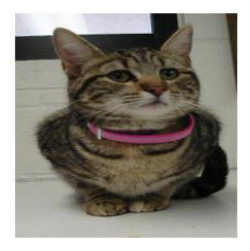

Image 1:
Actual : Cat | Predicted : Cat
Dog probablity : 0.1181



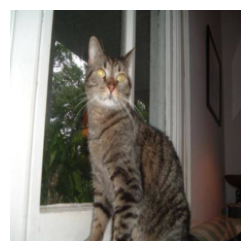

Image 2:
Actual : Cat | Predicted : Dog
Dog probablity : 0.9393



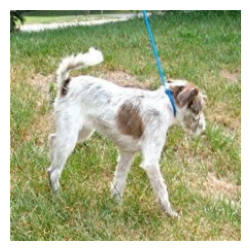

Image 3:
Actual : Dog | Predicted : Dog
Dog probablity : 1.0000



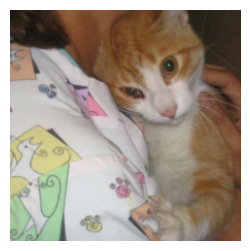

Image 4:
Actual : Cat | Predicted : Cat
Dog probablity : 0.0272



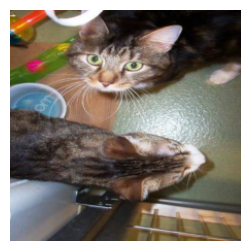

Image 5:
Actual : Cat | Predicted : Dog
Dog probablity : 0.9138



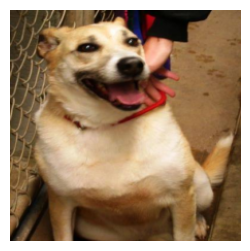

Image 6:
Actual : Dog | Predicted : Cat
Dog probablity : 0.2595



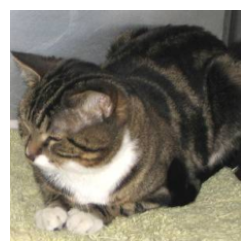

Image 7:
Actual : Cat | Predicted : Cat
Dog probablity : 0.0591



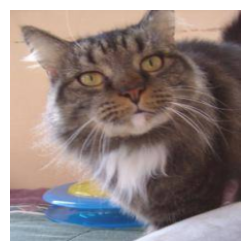

Image 8:
Actual : Cat | Predicted : Cat
Dog probablity : 0.0001



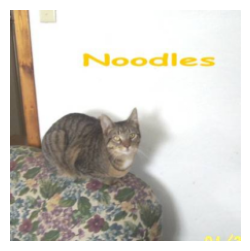

Image 9:
Actual : Cat | Predicted : Cat
Dog probablity : 0.1440



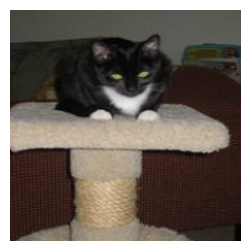

Image 10:
Actual : Cat | Predicted : Cat
Dog probablity : 0.0007



In [28]:
model.eval()
images,labels =next(iter(val_loader))
with torch.no_grad():
  output=model(images)
  probability=torch.sigmoid(output)
  prediction=(probability>=.5).int()
for i in range(10):
  actual='Dog' if labels[i].item()==1 else 'Cat'
  predicted='Dog' if prediction[i].item()==1 else 'Cat'
  plt.figure(figsize=(3,3))
  #images shape [32,3,224,224] matplotlib needs height*widh*channels so we use .permute()
  image=images[i].permute(1,2,0)
  plt.imshow(image)
  plt.axis('off')
  plt.show()
  print(
      f'Image {i+1}:\n'
      f'Actual : {actual} | '
      f'Predicted : {predicted}\n'
      f'Dog probablity : {probability[i].item():.4f}\n'
  )


###Deployment / Test

In [42]:
model.eval()
correct=0
total=0
total_loss=0

with torch.no_grad():
  for images,labels in test_loader:
    output=model(images)
    loss=loss_fx(output,labels.float().unsqueeze(1))
    total_loss+=loss
    probablity=torch.sigmoid(output)
    prediction=(probablity>=.5).int()
    correct += (prediction.squeeze(1) == labels).sum().item()
    total+=labels.size(0)
  test_accuracy=(correct/total)*100
  test_loss=total_loss/len(test_loader)

print(
    f'Test Accuracy : {test_accuracy:.4f} \n%'
    f'Average Loss  : {test_loss}'
)



Test Accuracy : 68.6667 
%Average Loss  : 1.2723642587661743
